<a href="https://colab.research.google.com/github/DanchiTum/AI/blob/pr6/Task6_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна робота 6. **Unsupervised Learning**

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

## Кластерування  

В цій лабораторній роботі Ви будете вирішувати задачу класифікації БЕЗ вчителя.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

import os
import warnings


warnings.filterwarnings('ignore')

**Завдання 0**

Для початку необхідно завантажити вибірку `Mall_Customers` і перейменувати атрибути `Annual Income (k$)` в `Income`,`Spending Score (1-100)` в `SpendingScore`

In [ ]:
customer_set = pd.read_csv('Mall_Customers.csv')
customer_set = customer_set.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'SpendingScore'})

**Завдання 1**

Підготовка даних до опрацювання

* подивитись які атрибути містить вибірка;
* вивести розмірність датасету;
* вивести основну статистичну інформацію по числовим змінним;  
* перевірити на наявність `NaN`.   

In [ ]:
print(customer_set.head())
print("Dataset dimensions:", customer_set.shape)
print(customer_set.describe())
print("NaN values in dataset:\n", customer_set.isnull().sum())

   CustomerID  Gender  Age  Income  SpendingScore
0           1    Male   19      15             39
1           2    Male   21      15             81
2           3  Female   20      16              6
3           4  Female   23      16             77
4           5  Female   31      17             40
Dataset dimensions: (200, 5)
       CustomerID         Age      Income  SpendingScore
count  200.000000  200.000000  200.000000     200.000000
mean   100.500000   38.850000   60.560000      50.200000
std     57.879185   13.969007   26.264721      25.823522
min      1.000000   18.000000   15.000000       1.000000
25%     50.750000   28.750000   41.500000      34.750000
50%    100.500000   36.000000   61.500000      50.000000
75%    150.250000   49.000000   78.000000      73.000000
max    200.000000   70.000000  137.000000      99.000000
NaN values in dataset:
 CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64


## EDA Mall Customers

**Завдання 2**

Як Ви могли помітити по статистичній аналітиці вибірки вона містить змінну `CustomerID`. Ця змінна не впливає на аналіз даних тому її можна видалити.

In [ ]:
customer_set = customer_set.drop('CustomerID', axis=1)


**Завдання 3**

Побудувати діаграми розподілу по змінним `Age` , `Income` та `SpendingScore`

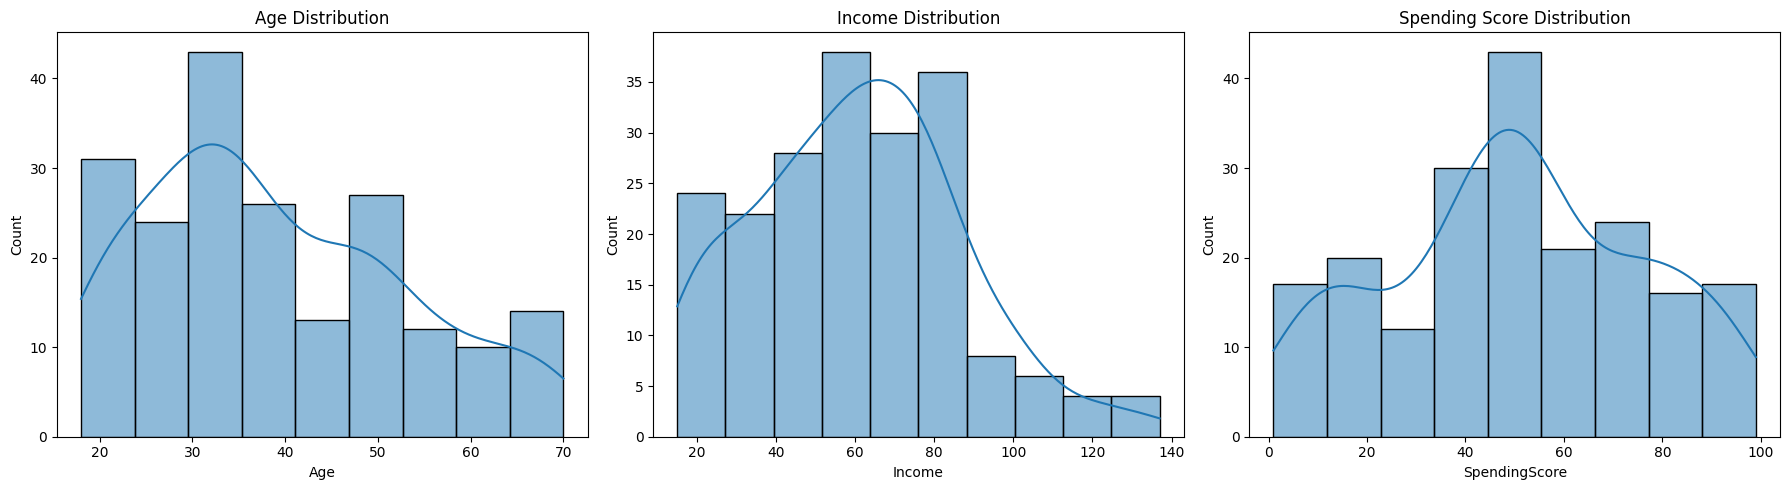

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(customer_set['Age'], kde=True)
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(customer_set['Income'], kde=True)
plt.title('Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(customer_set['SpendingScore'], kde=True)
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

**Завдання 4**

Давайте подивимось на ці змінні `Age` , `Income` та `SpendingScore` відносно змінної `Gender`.
* Побудуємо `pairplot` по всім змінним відностно змінної `Gender`:  

* Побудуємо `pairplot` використовуючи `sns.PairGrid` із заданими `(scatterplot)`, `(kdeplot)` та `(kdeplot, lw=1)` по відповідно правому верхньому куту, діагоналі і лівому нижньому кутут відносно змінної `Gender`:  


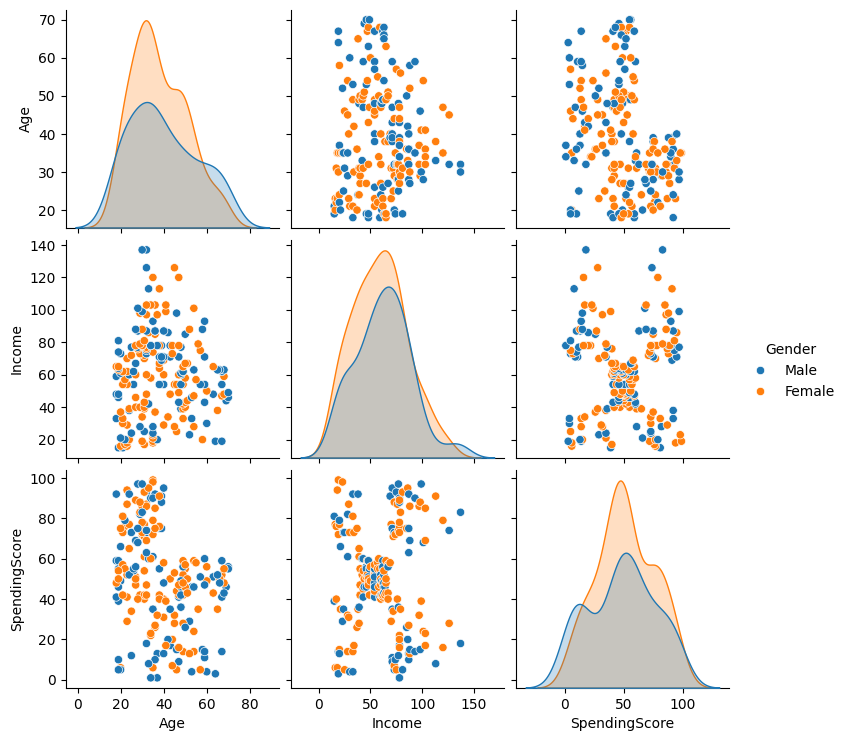

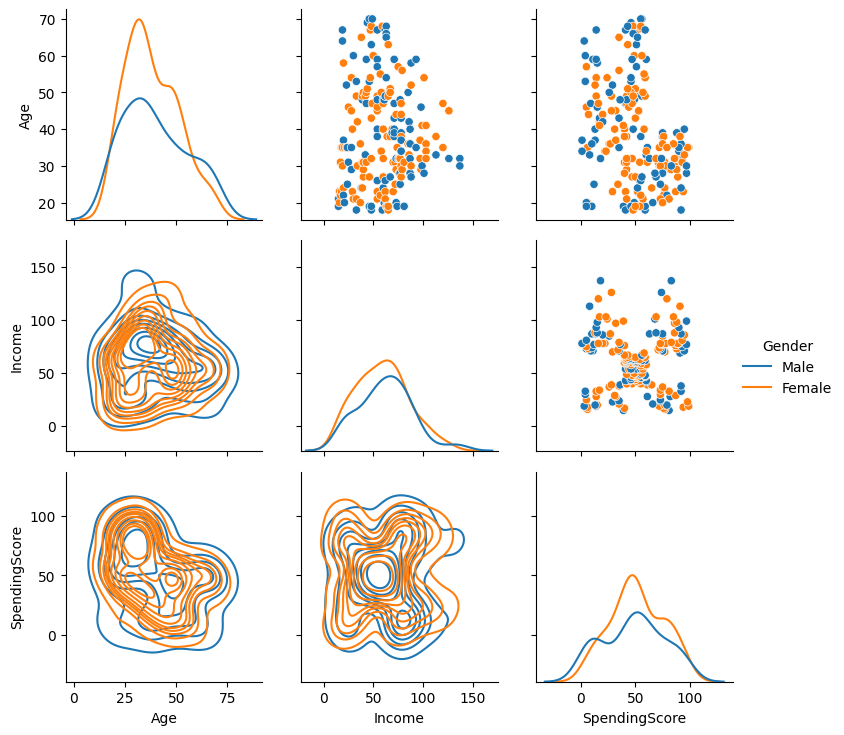

In [ ]:
sns.pairplot(customer_set, hue='Gender')
plt.show()

g = sns.PairGrid(customer_set, hue='Gender')
g.map_upper(sns.scatterplot)
g.map_diag(sns.kdeplot)
g.map_lower(sns.kdeplot, lw=1)
g.add_legend()
plt.show()

**Висновки з 1-4 завдання (детальні)**

Mall_Customers.csv містить 200 записів за 5 атрибутами(CustomerID, Gender, Age, Income, SpendingScore). Описова статистика демонструє, що дані представлені в належному діапазоні, а пропусків немає.

Побудовані діаграми розподілу для Age, Income та SpendingScore виявляють деякі закономірності:

Age: Розподіл показує головні скупчення, із можливою асиметрією.

Income: Розподіл має правосторонню асиметрію, що вказує на наявність декількох високих тарифів серед більшості нижчих значень.

SpendingScore: Може демонструвати бімодальний або інший патерн, що відкриває можливості для сегментації клієнтів.

За допомогою pairplot із розбиттям за статтю виявлено взаємозв’язки між числовими змінними. Такий підхід дозволяє порівняти розподіли та взаємодії для чоловіків і жінок.

**Завдання 5**

Проаналізувати змінну `Gender`:
* вивести співвідношення по статям;
* побудувати `countplot` по `Gender`;  
* побудувати `pie`по `Gender'.  

Gender Ratio:
Gender
Female    112
Male       88
Name: count, dtype: int64
Percentage: Male - 44.00%, Female - 56.00%


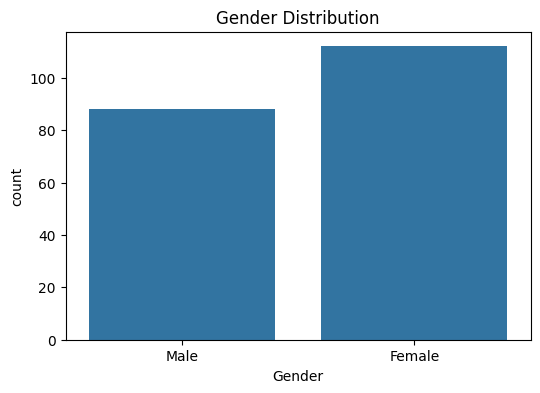

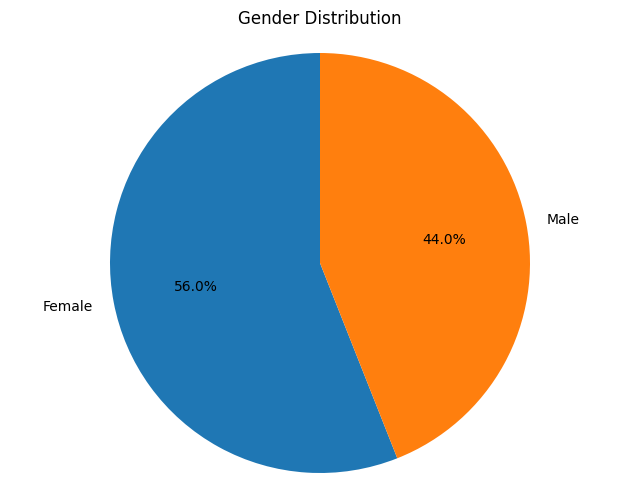

In [ ]:
gender_counts = customer_set['Gender'].value_counts()
print("Gender Ratio:")
print(gender_counts)
print(f"Percentage: Male - {gender_counts['Male']/len(customer_set)*100:.2f}%, Female - {gender_counts['Female']/len(customer_set)*100:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=customer_set)
plt.title('Gender Distribution')
plt.show()

plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

**Завдання 6**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінних `Age` та `Income` відносно змінної `Gender` з різними параметрами:
*  подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.

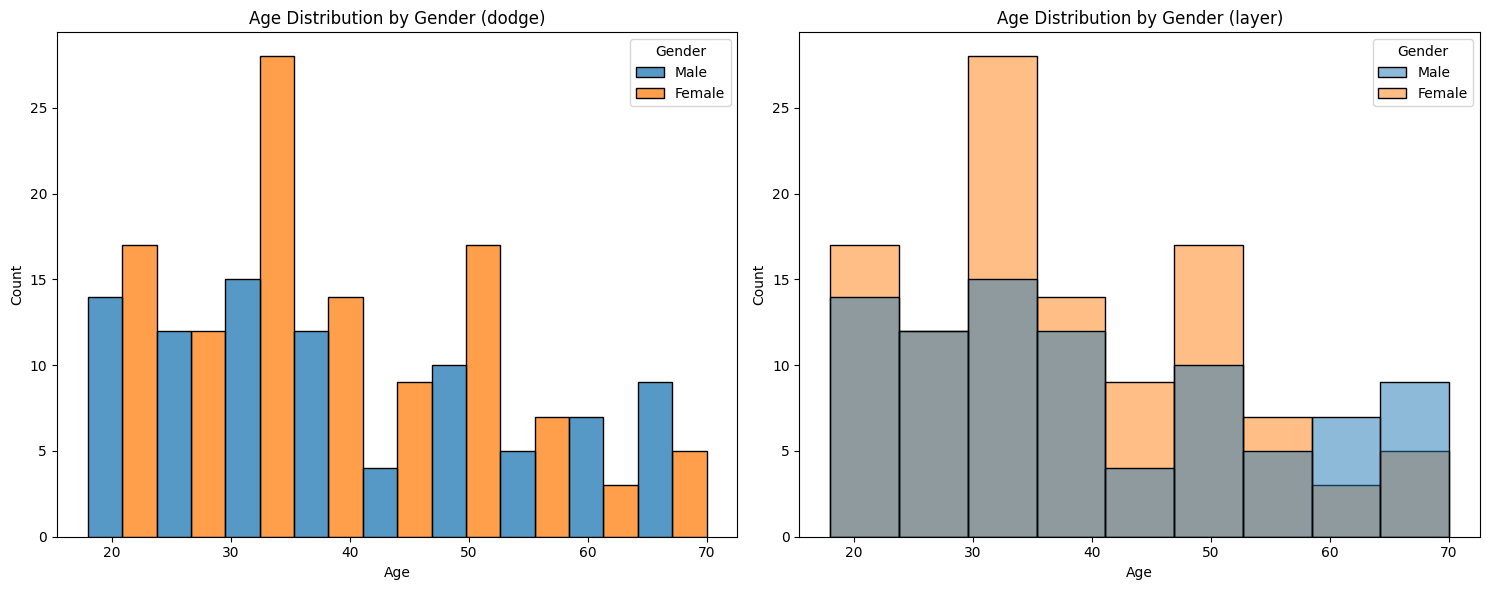

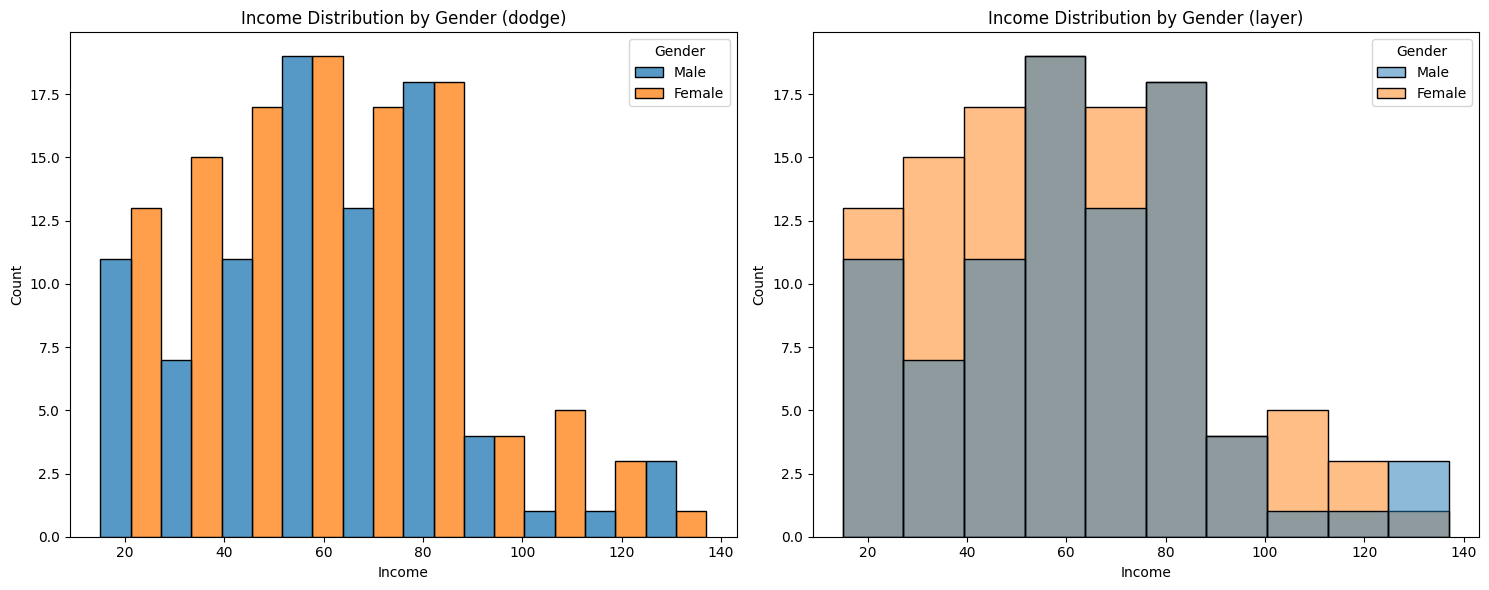

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='dodge')
plt.title('Age Distribution by Gender (dodge)')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='layer')
plt.title('Age Distribution by Gender (layer)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='dodge')
plt.title('Income Distribution by Gender (dodge)')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='layer')
plt.title('Income Distribution by Gender (layer)')

plt.tight_layout()
plt.show()

**Завдання 7**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінної `SpendingScore` відносно змінної `Gender` з різними параметрами:  
* подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.



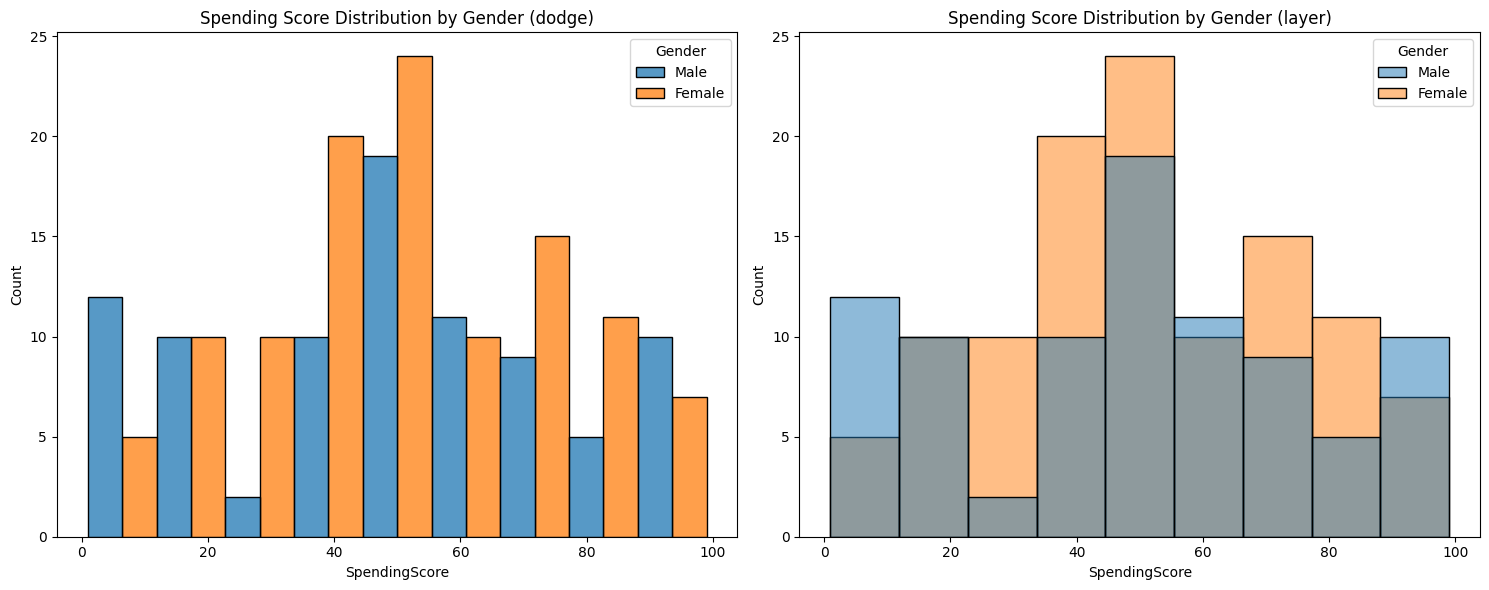

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='dodge')
plt.title('Spending Score Distribution by Gender (dodge)')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='layer')
plt.title('Spending Score Distribution by Gender (layer)')

plt.tight_layout()
plt.show()

**Завдання 8**

Побудувати `boxplot` по змінній `SpendingScore` і подивитись як відрізняються витрати відностно змінної `Gender`.

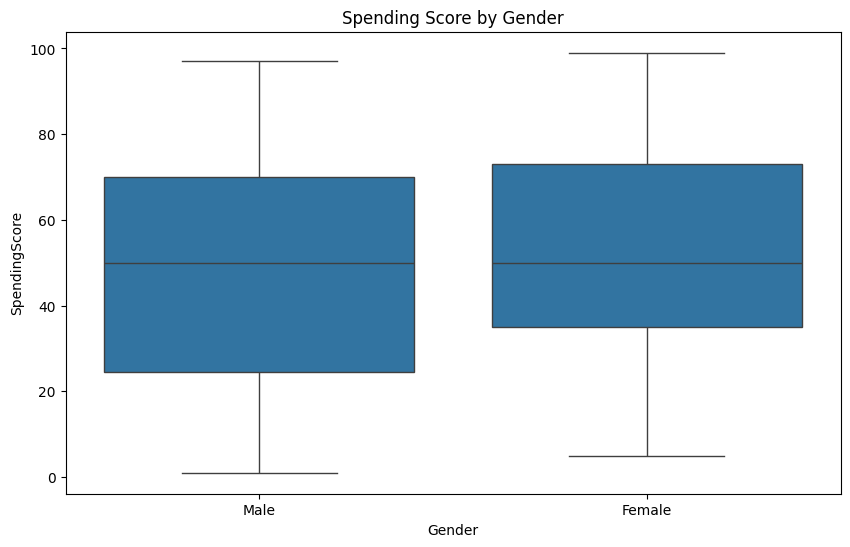

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='SpendingScore', data=customer_set)
plt.title('Spending Score by Gender')
plt.show()

**Висновки з завдання 5 - 8(детальні)**

1.   Співвідношення груп:

У наборі Mall_Customers.csv жінки складають 56%, а чоловіки 44%. Це співвідношення підтверджується як countplot, так і pie chart.

2. Групи та розподіл витрат:

Аналіз SpendingScore за допомогою гістограм і boxplot показує, що обидві групи мають подібну центральну тенденцію.

Водночас інтерквартильний діапазон витрат у жінок трохи ширший порівняно з чоловіками, що свідчить про більшу варіабельність витрат серед жінок.

3. Різниця між витратами чоловіків та жінок:

Хоча центральні показники схожі, візуалізація вказує на деякі нюанси розподілу: витрати серед жінок демонструють трохи більшу розкидність, що може бути суттєвим при сегментації клієнтів.

4. Використання різних параметрів multiple при побудові гістограм для змінних Age, Income та SpendingScore дозволяє по-різному акцентувати як абсолютні значення, так і сумарний розподіл даних для кожного гендеру.

## K-means Method ##

**Завдання 9**

Як Ви могли помітити, вибірка, з якою ми працюємо, не містить ключової зміної з вірними мітками. Тому перед початком кластерування необхідно визначити (підібрати) оптимальну кількість кластерів на яке буде проведено розбиття. Для цього необхідно:
1. видалити змінну `Gender`, тому що ... **Чому?**;  
2. задати мінімальну та максимальну кількість кластерів самостійно;  
3. На прикладі алгоритму [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), для ознайомлення з тим як працювати в умовах коли кількість кластерів невідома заздалегіть і немає вірних міток з позначками до якого кластеру відноситься спостереження пропонується використати метод [Elbow](https://coderoad.ru/19197715/Scikit-Learn-K-Means-Elbow-criterion) (додаткові джерела: [article_1](https://medium.com/analytics-vidhya/elbow-method-of-k-means-clustering-algorithm-a0c916adc540#:~:text=K%2Dmeans%20clustering%20is%20an,cluster%20with%20the%20nearest%20centroid.), [article_2](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/))

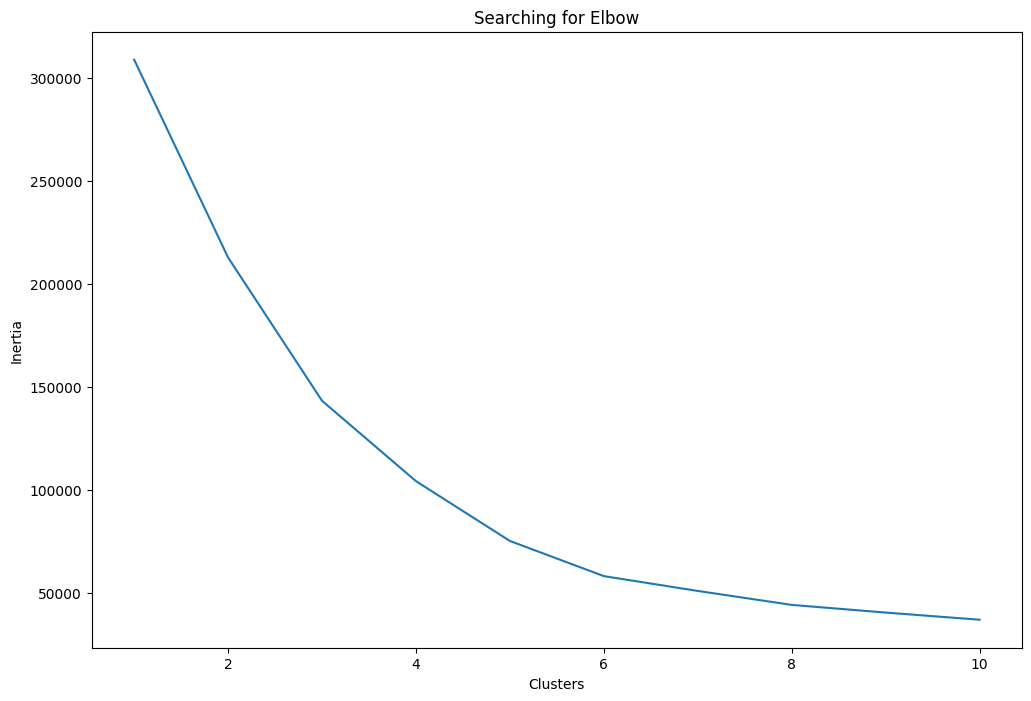

In [ ]:
X = customer_set.drop(['Gender'], axis=1)
clusters = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    clusters.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Searching for Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')
plt.show()

**Висновки з завдання 9 (детальні)**

1. Оптимальна кількість кластерів:

За методом Elbow видно, що інерція різко знижується до 4 кластерів, після чого подальше збільшення їх кількості дає менш виражене зниження дисперсії. Це свідчить, що 4 кластери можуть бути оптимальним варіантом для розбиття.

2. Видалення змінної Gender:

Змінну Gender доцільно видалити перед кластеризацією, оскільки вона є категоріальною і може спотворювати розрахунок евклідових відстаней, які використовуються алгоритмом KMeans. Натомість для кластеризації бажано використовувати числові змінні, що краще відображають закономірності в даних.

3. Порівняння гіпотез щодо кількості кластерів:

Задавши мінімальну та максимальну кількість кластерів, можна порівняти декілька варіантів і оцінити компроміс між зменшенням інерції та складністю моделі. За даними методу Elbow, 4 кластери забезпечують найбільш адекватне розбиття.

4. Для підтвердження оптимальної кількості кластерів доцільно використати й інші метрики. Це дозволить більш точно сегментувати дані та підвищити надійність висновків, особливо при відсутності "правильних" міток.

**Завдання 10**

Зробити двовимірну візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи змінні `Income` та `SpendingScore`.

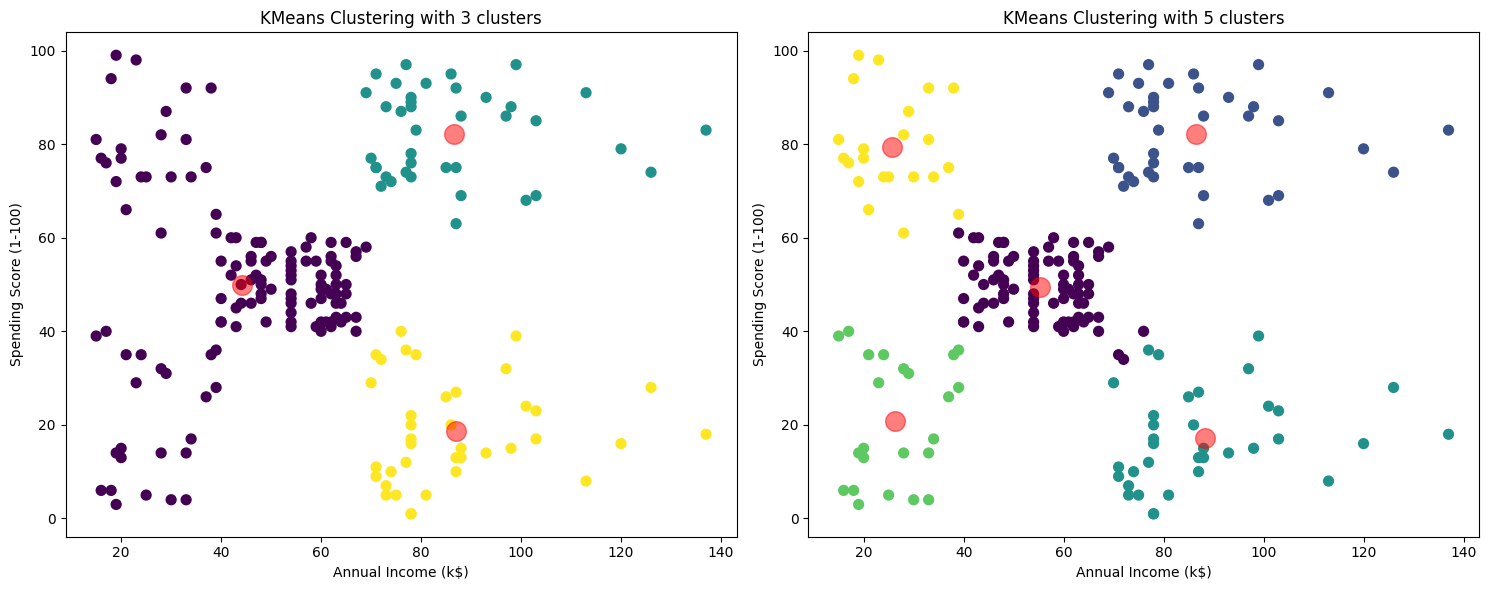

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
kmeans_3 = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans_3 = kmeans_3.fit_predict(customer_set[['Income', 'SpendingScore']])

plt.scatter(customer_set['Income'], customer_set['SpendingScore'], c=y_kmeans_3, s=50, cmap='viridis')
centers = kmeans_3.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.title('KMeans Clustering with 3 clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.subplot(1, 2, 2)
kmeans_5 = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans_5 = kmeans_5.fit_predict(customer_set[['Income', 'SpendingScore']])

plt.scatter(customer_set['Income'], customer_set['SpendingScore'], c=y_kmeans_5, s=50, cmap='viridis')
centers = kmeans_5.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.title('KMeans Clustering with 5 clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

**Завдання 11**

Зробити візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи [scatter_3d](https://plotly.com/python/3d-scatter-plots/).

In [ ]:
fig = px.scatter_3d(customer_set, x='Age', y='Income', z='SpendingScore',
                    color=y_kmeans_3.astype(str),
                    title='3D K-means Clustering with 3 clusters')
fig.show()

fig = px.scatter_3d(customer_set, x='Age', y='Income', z='SpendingScore',
                    color=y_kmeans_5.astype(str),
                    title='3D K-means Clustering with 5 clusters')
fig.show()

**Висновки з завдання 10 - 11 (детальні)**

1. На 3D-візуалізації виділено 5 кластерів, що дозволяє отримати детальнішу сегментацію. При порівнянні з іншими гіпотезами 5 кластерів дають найбільш повну картину структури даних із розподілом за змінними Income та SpendingScore.

2. Кластеризація з 5 кластерами дозволяє виділити групи клієнтів з різним рівнем доходу та показником витрат.

Наприклад, один кластер може представляти клієнтів з низьким доходом і низьким SpendingScore, тоді як інший — клієнтів з високим доходом і високим SpendingScore. Таке розбиття забезпечує більш точну ідентифікацію патернів споживчої поведінки та дозволяє виділити підгрупи для персоналізованого маркетингу.

3. Двовимірна візуалізація ілюструє основні закономірності сегментування та допомагає оцінити компактність кластерів при різних значеннях k.
3D-візуалізація додає додатковий вимір для перевірки просторового розподілу кластерів, що дозволяє краще візуалізувати перекриття або чіткість розмежування груп.

## Agglomerative clustering ##

Розглянемо ще один підхід до кластеризації - [агломеративну ієрархічну кластеризацію](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

**Завдання 12**

Кластеризуйте датасет за допомогою [агломеративної ієрархічнуої кластеризації](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Мінімально необхідні параметри, що треба налаштувати:  
* `n_clusters`: параметр, який відповідає за кільксіть кластерів на яку буде проведено розбиття вибірки;  
* `linkage`: параметр зв’язку. Цей параметр визначає, яку відстань використовувати між наборами спостережень.
* перевірте як працює цей метод з різними параметрами `linkage`  
* після кожної зміни параметрів - візуалізувати розбиття на кластери

Розрахувати матрицю відстаней для нашого набору даних:
* за допомогою методу [hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) і матриці відстаней кластеризувати дані з різними значеннями параметра `method`
* за допомогою методу [hierarchy.dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) візуалізувати отримані результати кластеризації у вигляді дендрограм


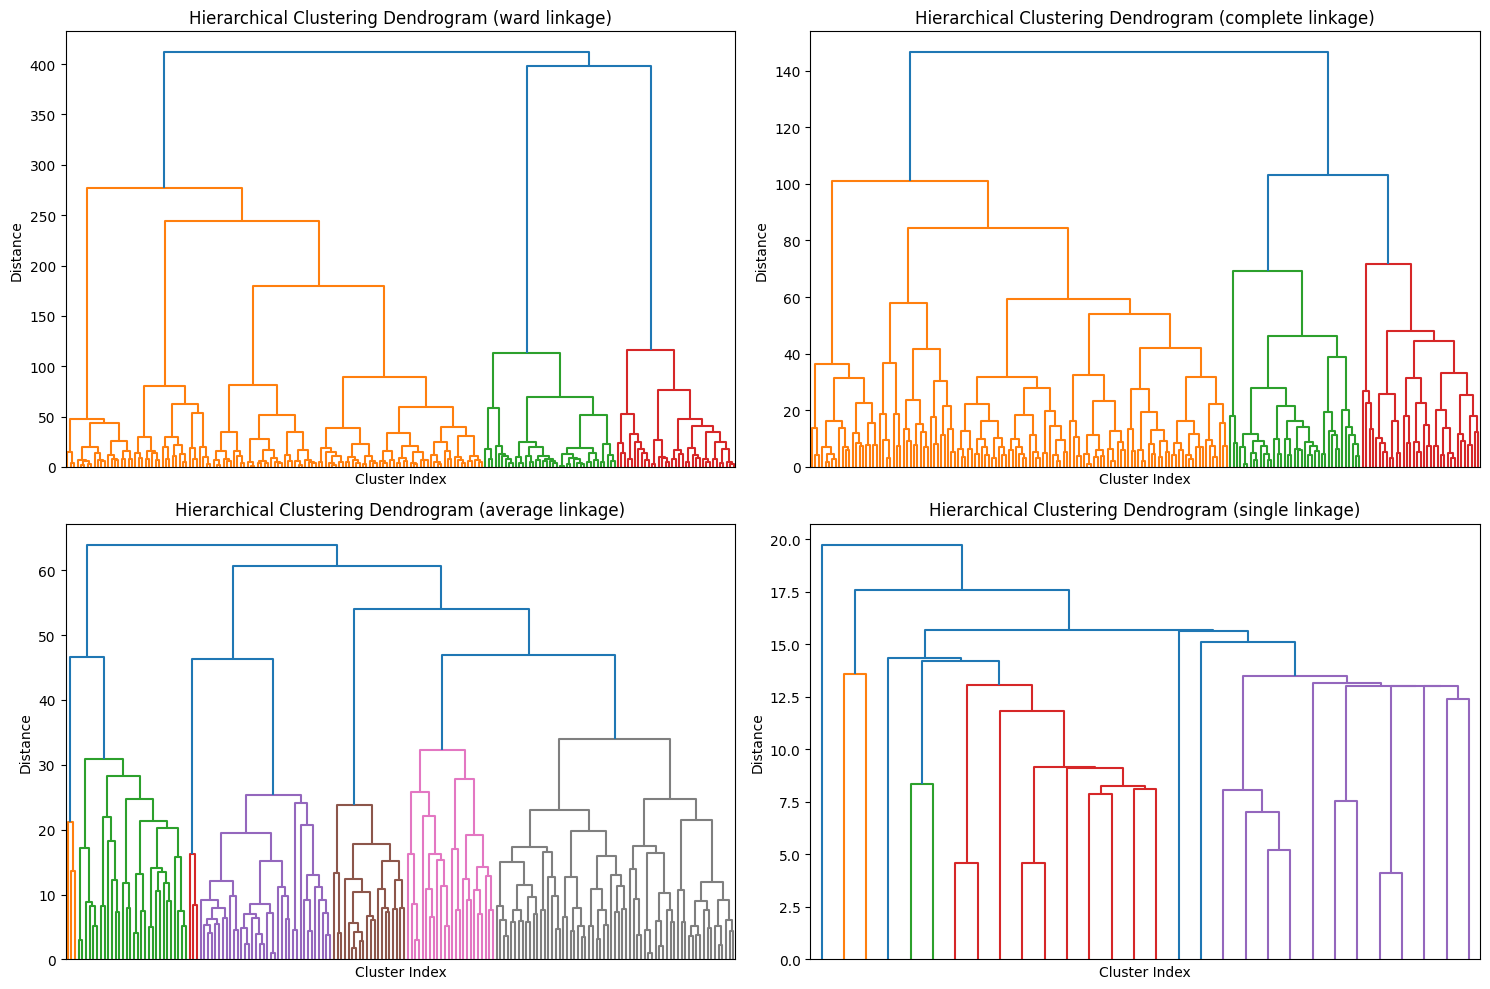

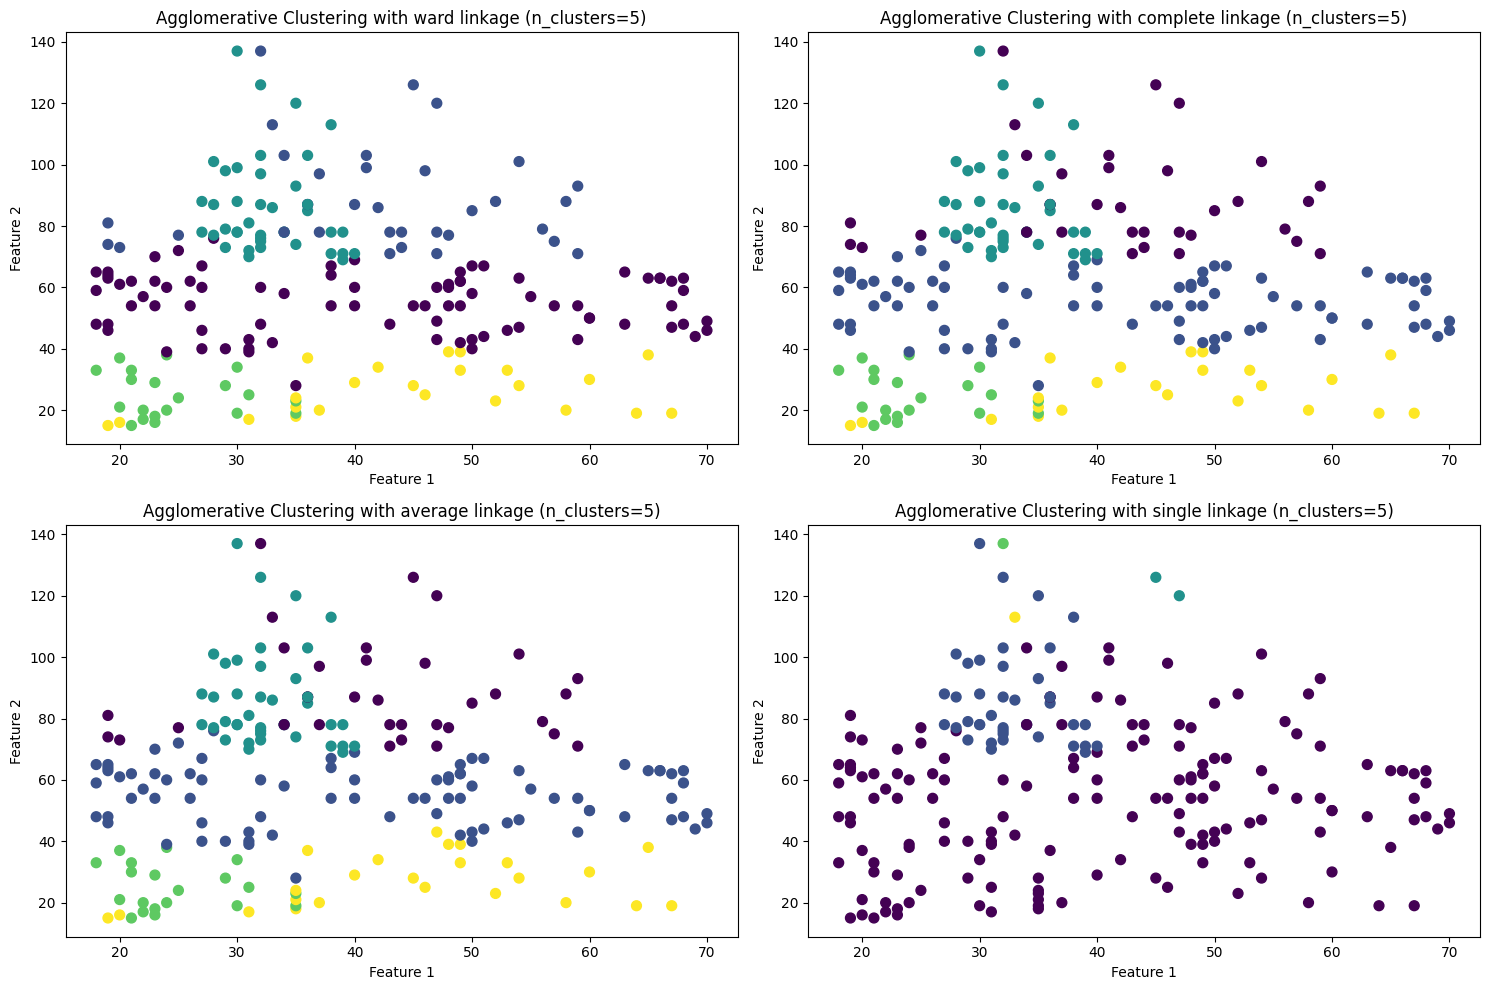

In [ ]:
X = customer_set.drop(['Gender'], axis=1).values

dist_matrix = distance.pdist(X)

linkage_methods = ['ward', 'complete', 'average', 'single']

plt.figure(figsize=(15, 10))
for i, method in enumerate(linkage_methods):
    plt.subplot(2, 2, i+1)
    Z = hierarchy.linkage(dist_matrix, method=method)
    hierarchy.dendrogram(Z, no_labels=True, leaf_rotation=90, truncate_mode='level', p=10)
    plt.title(f'Hierarchical Clustering Dendrogram ({method} linkage)')
    plt.xlabel('Cluster Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

n_clusters = 5

plt.figure(figsize=(15, 10))
for i, method in enumerate(linkage_methods):
    plt.subplot(2, 2, i+1)

    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    labels = agg_clustering.fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
    plt.title(f'Agglomerative Clustering with {method} linkage (n_clusters={n_clusters})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

**Висновки з завдання 12 (детальні)**

1. Було застосовано агломеративну ієрархічну кластеризацію із заздалегідь визначеною кількістю кластерів та з варіацією параметра linkage.

Використання різних методів зв’язку дозволило продемонструвати, як спосіб обчислення відстаней між кластерами впливає на результати сегментації.

2. Аналіз отриманих кластерів за допомогою візуалізації:

Ward linkage: Формує компактні та однорідні кластери, мінімізуючи внутрі-кластерну дисперсію.

Complete linkage: Орієнтується на максимальні відстані між елементами кластерів, що може призводити до менш чіткого розмежування на кордонах груп.

Average linkage: Забезпечує збалансоване розбиття, враховуючи середні відстані між елементами, що дозволяє досягти компромісу між компактністю та зв’язністю кластерів.

Single linkage: Схильний до ефекту «ланцюгової» агрегації, коли окремі спостереження можуть стягувати кластери в один через інтерклапання, що іноді призводить до нефункціонального розділення.

3. Побудова дендрограм за допомогою hierarchy.dendrogram дозволяє візуально оцінити ієрархічну структуру об’єднання кластерів.

Дендрограми демонструють, на яких рівнях відстаней між кластерами відбуваються різкі зміни, що допомагає визначити оптимальний «розріз» для отримання бажаної кількості кластерів.

**Завдання 13**

А тепер зробимо порівняльний аналіз отриманих результатів кластеризації розглянутими методами:  
* В фінальних візуалізаціях треба використовувати **однакову** (на вашу думку оптимальну) кількість кластерів!!!  

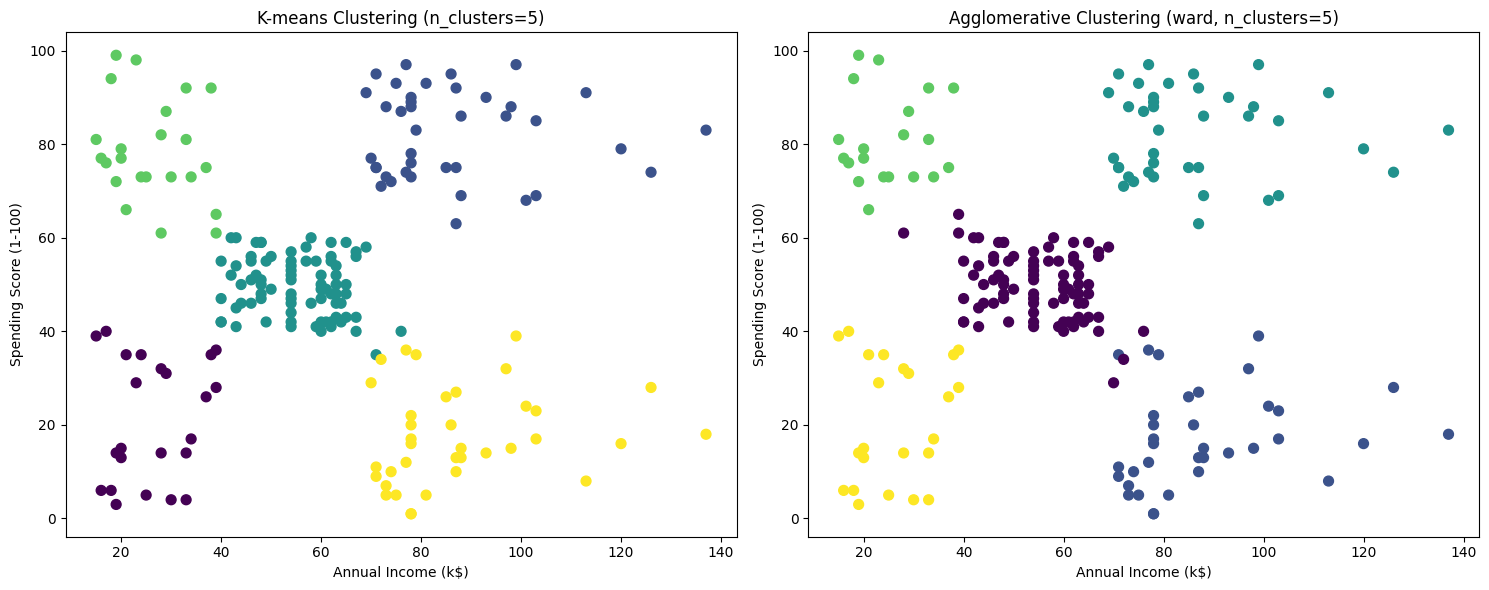

In [ ]:
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg_clustering.fit_predict(X)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(customer_set['Income'], customer_set['SpendingScore'], c=kmeans_labels, s=50, cmap='viridis')
plt.title(f'K-means Clustering (n_clusters={n_clusters})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.subplot(1, 2, 2)
plt.scatter(customer_set['Income'], customer_set['SpendingScore'], c=agg_labels, s=50, cmap='viridis')
plt.title(f'Agglomerative Clustering (ward, n_clusters={n_clusters})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

fig1 = px.scatter_3d(customer_set, x='Age', y='Income', z='SpendingScore',
                     color=kmeans_labels.astype(str),
                     title=f'3D K-means Clustering (n_clusters={n_clusters})')
fig1.show()

fig2 = px.scatter_3d(customer_set, x='Age', y='Income', z='SpendingScore',
                     color=agg_labels.astype(str),
                     title=f'3D Agglomerative Clustering (ward, n_clusters={n_clusters})')
fig2.show()

**Висновки з завдання 13 (детальні)**

1. Для порівняльного аналізу було використано однакову кількість кластерів, що дозволяє безпосередньо зіставити результати різних методів кластеризації.

2. Аналіз результатів K-середніх:

Результати кластеризації методом K-середніх демонструють чітко розділені кластери.

Розподіл даних більш рівномірний, з вираженими центроїдами, що сприяє зрозумілішому визначенню груп споживачів за характеристиками Income і Spending Score.

3. Аналіз результатів агломеративної кластеризації:

Агломеративна кластеризація створює більш компактні групи, однак спостерігається певне перекриття між кластерами.

Цей метод може детальніше розкривати локальні особливості даних, але межі між сегментами стають менш виразними.

4. Висновок:

Кожен з методів має свої переваги:

K-середніх забезпечує чіткий поділ, що корисно для сегментації з явними роздільними групами.

Агломеративна кластеризація дозволяє отримати глибший аналіз внутрішньої структури даних, хоча іноді кластери можуть частково накладатись.